<a href="https://colab.research.google.com/github/rakesh-mandal/credit-card-fraud-detection/blob/main/fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Card Fraud Detection

End-to-end pipeline for detecting fraudulent credit card transactions using the [Kaggle Credit Card Fraud dataset](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud).

**Pipeline:** EDA → feature scaling → SMOTE oversampling (train folds only) → model comparison (Logistic Regression, Random Forest, XGBoost) via stratified 5-fold CV → threshold tuning via out-of-fold predictions → final evaluation on a held-out test set.

See `README.md` for setup instructions and results summary.

## 0. Output Folder for Figures

Creates an `images/` folder to save each plot as a PNG. These get embedded in the README and are downloaded at the end of the notebook (Colab doesn't persist local files between sessions).

In [1]:
import os
os.makedirs('images', exist_ok=True)


## 1. Setup

Install the Kaggle CLI and download the dataset directly from Kaggle so the raw data never has to be committed to this repo.

In [2]:
# Install Kaggle CLI
!pip -q install kaggle

In [3]:
# Kaggle API setup (Colab)
# 1. Go to https://www.kaggle.com/settings -> API section -> 'Create New Token'
# 2. Copy the token value shown (starts with 'KGAT_...')
# 3. In Colab, click the key icon in the left sidebar ('Secrets')
# 4. Add a new secret named KAGGLE_API_TOKEN, paste the token as its value,
#    and toggle 'Notebook access' on
#
# This keeps the token out of the notebook file entirely -- never paste the
# raw token directly into a code cell, since notebooks are easy to accidentally
# commit to GitHub with secrets still inside them.

from google.colab import userdata
import os

os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

assert os.environ.get('KAGGLE_API_TOKEN'), \
    'KAGGLE_API_TOKEN not found. Add it in Colab Secrets before downloading the dataset.'


In [4]:
!kaggle datasets download -d mlg-ulb/creditcardfraud

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
100% 66.0M/66.0M [00:00<00:00, 201MB/s]



In [5]:
!unzip -o creditcardfraud.zip

Archive:  creditcardfraud.zip
  inflating: creditcard.csv          


## 2. Imports

Libraries for data handling and visualization (`pandas`, `numpy`, `matplotlib`, `seaborn`), model training and evaluation (`scikit-learn`, `xgboost`), and imbalance handling (`imbalanced-learn`'s `SMOTE`).

In [6]:

import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, cross_val_predict
)

from sklearn.preprocessing import RobustScaler, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


from imblearn.pipeline import Pipeline


from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve

from imblearn.over_sampling import SMOTE

## 3. Load & Inspect the Data

Basic data-quality checks before modeling: confirm the shape, column types, and that there are no missing values. This dataset's features (`V1`–`V28`) are already PCA-anonymized by the dataset providers, so no further anonymization is needed.

In [7]:
df = pd.read_csv("creditcard.csv")

In [8]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [9]:
df.shape


(284807, 31)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [11]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [12]:
df.isnull().sum().max()

0

In [13]:
df["Class"].value_counts()

,count
Class,
0,284315
1,492


In [14]:
df["Class"].value_counts(normalize=True) * 100

,proportion
Class,
0,99.827251
1,0.172749


 NOTE: 99.83% of transactions are genuine and only 0.17% are fraudulent.

A quick visual of the class imbalance shown above — the fraud bar is barely visible next to genuine transactions. This is the central challenge of the whole project: a model that predicts "genuine" for every transaction would score ~99.8% accuracy while catching zero fraud, so accuracy alone is a misleading metric here.

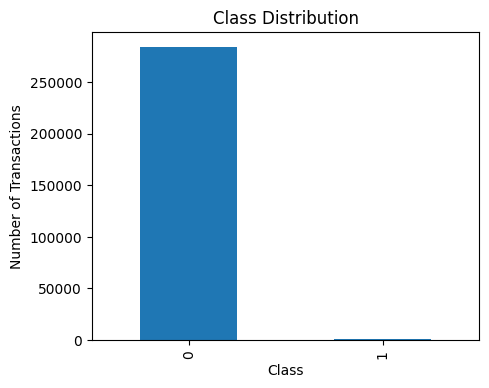

In [15]:
plt.figure(figsize=(5,4))
df["Class"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")
plt.savefig('images/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Feature Exploration

Looking at `Amount` and `Time` in more detail, since these are the only two human-interpretable features (`V1`–`V28` are anonymized PCA components). The goal is to see whether fraud transactions differ systematically from genuine ones in these dimensions.

In [16]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [17]:
df["Amount"].describe()

,Amount
count,284807.000000
mean,88.349619
std,250.120109
min,0.000000
25%,5.600000
50%,22.000000
75%,77.165000
max,25691.160000


In [18]:
df['Amount'].values

array([149.62,   2.69, 378.66, ...,  67.88,  10.  , 217.  ])

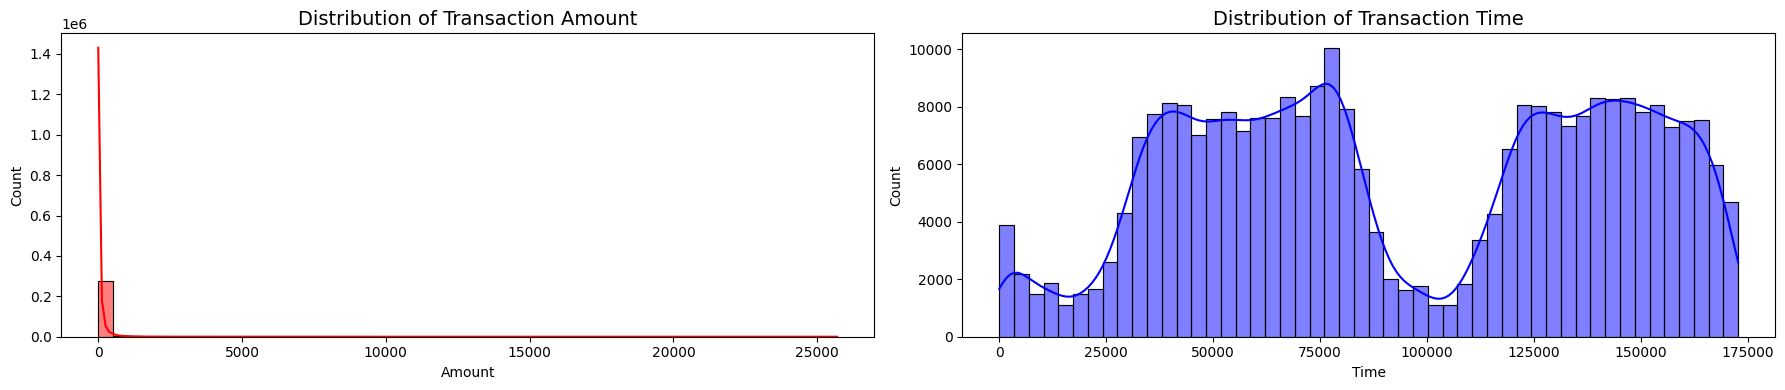

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(18, 4))

amount_val = df['Amount'].values
time_val = df['Time'].values

sns.histplot(amount_val, bins=50, kde=True, ax=ax[0], color='red')
ax[0].set_title('Distribution of Transaction Amount', fontsize=14)
ax[0].set_xlabel('Amount')

sns.histplot(time_val, bins=50, kde=True, ax=ax[1], color='blue')
ax[1].set_title('Distribution of Transaction Time', fontsize=14)
ax[1].set_xlabel('Time')

plt.tight_layout()
plt.savefig('images/amount_time_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:** `Amount` is heavily right-skewed — the vast majority of transactions are small, with a long tail of rare, very large transactions (up to ~$25,000). `Time` shows a clear bimodal pattern with two roughly 24-hour cycles (this dataset spans ~2 days), dipping during likely nighttime hours and peaking during the day — consistent with normal human spending patterns rather than fraud-specific behavior.


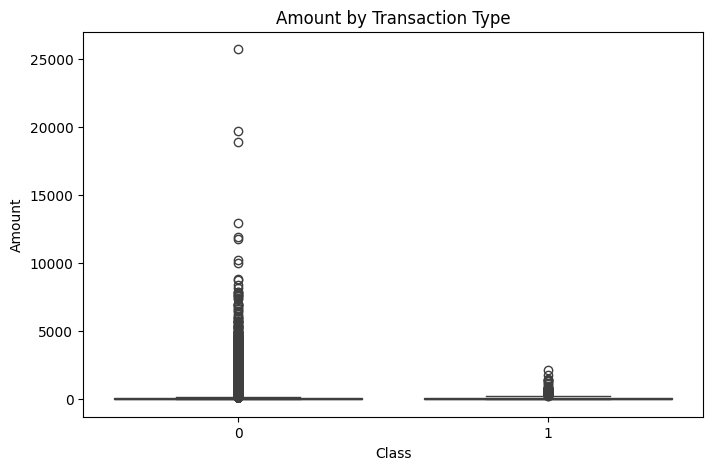

In [20]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Class", y="Amount", data=df)

plt.title("Amount by Transaction Type")

plt.savefig('images/amount_by_class_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:** Fraudulent transactions (`Class=1`) cluster at noticeably lower amounts than genuine ones, with a much narrower spread — genuine transactions include extreme outliers up to \$25,000,  while fraud rarely exceeds ~$2,000. This suggests fraudsters may deliberately keep transaction amounts low to avoid triggering scrutiny, which is a useful (if imperfect) signal for the model.

**Correlation matrix** — checking which PCA features move together and which ones are most associated with the `Class` label. This helps sanity-check the data and hints at which features might matter most for the model later.

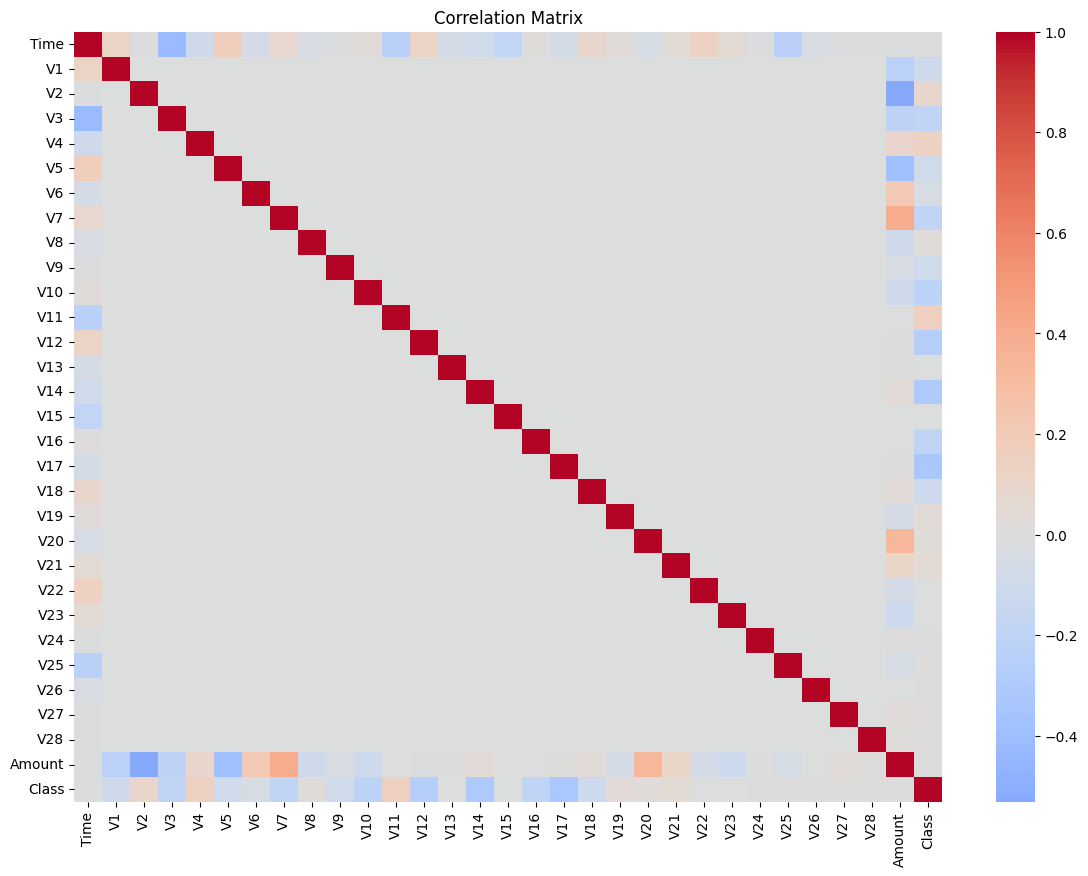

In [21]:
plt.figure(figsize=(14,10))

corr = df.corr()

sns.heatmap(corr,
            cmap="coolwarm",
            center=0)

plt.title("Correlation Matrix")

plt.savefig('images/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

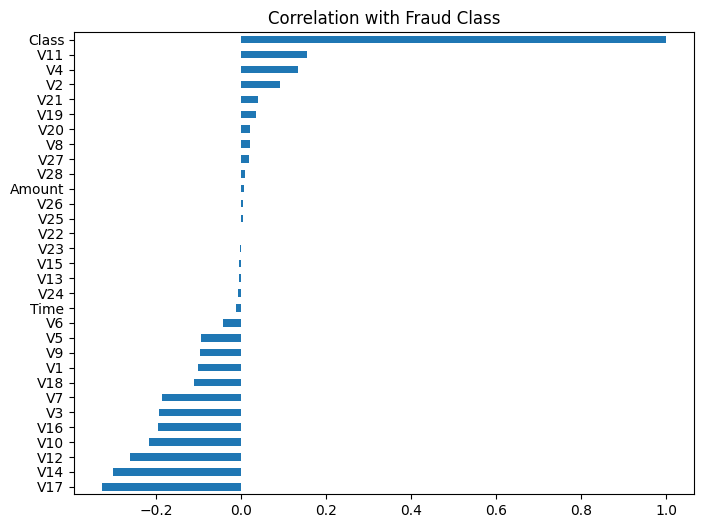

In [22]:
plt.figure(figsize=(8,6))

corr = df.corr()["Class"].sort_values()

corr.plot(kind="barh")
plt.title("Correlation with Fraud Class")
plt.savefig('images/correlation_with_fraud.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:** `Class` itself shows correlation 1.0 with `Class` — trivial, and expected since it's being compared to itself, not a real signal. Setting that aside, the strongest **positive** correlations with fraud are `V11`, `V4`, and `V2`, while the strongest **negative** correlations are `V17`, `V14`, `V12`, `V10`, and `V16`. Since these are anonymized PCA components, their real-world meaning isn't known, but the fact that several features show |correlation| well above the rest suggests the fraud signal is concentrated in a relatively small subset of components — worth watching for in the feature importance plot later on.

In [23]:
corr

,Class
V17,-0.326481
V14,-0.302544
V12,-0.260593
V10,-0.216883
V16,-0.196539
V3,-0.192961
V7,-0.187257
V18,-0.111485
V1,-0.101347
V9,-0.097733


## 5. Train/Test Split

Separate features (`X`) from the target (`y`) before splitting, so the same split logic can be reused cleanly for both.

In [24]:
X = df.drop("Class", axis=1)

y = df["Class"]

Splitting into train (80%) and test (20%) sets. `stratify=y` is important here: because fraud is only ~0.17% of the data, a random split without stratification risks leaving the test set with very few (or zero) fraud examples, which would make evaluation unreliable. Stratifying preserves the same fraud ratio in both sets.

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [26]:
X_train.shape

(227845, 30)

In [27]:
X_test.shape

(56962, 30)

In [28]:
print("Original Dataset")
print(y.value_counts(normalize=True) * 100)

print("\nTraining Dataset")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest Dataset")
print(y_test.value_counts(normalize=True) * 100)

Original Dataset
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

Training Dataset
Class
0    99.827075
1     0.172925
Name: proportion, dtype: float64

Test Dataset
Class
0    99.827955
1     0.172045
Name: proportion, dtype: float64


## 6. Feature Scaling

`Amount` is scaled with `RobustScaler` (uses median/IQR, so it's less sensitive to the extreme outlier transactions common in financial data) and `Time` with `StandardScaler`. Both scalers are **fit only on the training set** and then applied to the test set — fitting on the full dataset would leak information from the test set into training.

In [29]:
standard_scaler = StandardScaler()
robust_scaler = RobustScaler()

X_train = X_train.copy()
X_test = X_test.copy()

# 3. FIT + TRANSFORM on Training Data ONLY
X_train['scaled_amount'] = robust_scaler.fit_transform(X_train[['Amount']])
X_train['scaled_time'] = standard_scaler.fit_transform(X_train[['Time']])

# 4. TRANSFORM ONLY on Test Data (using parameters learned from Train)
X_test['scaled_amount'] = robust_scaler.transform(X_test[['Amount']])
X_test['scaled_time'] = standard_scaler.transform(X_test[['Time']])
# 5. Drop original unscaled columns
X_train.drop(['Amount', 'Time'], axis=1, inplace=True)
X_test.drop(['Amount', 'Time'], axis=1, inplace=True)

In [30]:
X_train.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,scaled_amount,scaled_time
265518,1.946747,-0.752526,-1.355130,-0.661630,1.502822,4.024933,-1.479661,1.139880,1.406819,-0.157403,...,0.076197,0.297537,0.307915,0.690980,-0.350316,-0.388907,0.077641,-0.032248,-0.204315,1.411588
180305,2.035149,-0.048880,-3.058693,0.247945,2.943487,3.298697,-0.002192,0.674782,0.045826,0.284864,...,0.038628,0.228197,0.035542,0.707090,0.512885,-0.471198,0.002520,-0.069002,-0.264579,0.623141
42664,-0.991920,0.603193,0.711976,-0.992425,-0.825838,1.956261,-2.212603,-5.037523,0.000772,-2.009561,...,-2.798352,0.109526,-0.436530,-0.932803,0.826684,0.913773,0.038049,0.185340,2.130828,-1.130680
198723,2.285718,-1.500239,-0.747565,-1.668119,-1.394143,-0.350339,-1.427984,0.010010,-1.118447,1.756121,...,-0.139670,0.077013,0.208310,-0.538236,-0.278032,-0.162068,0.018045,-0.063005,-0.221294,0.794699
82325,-0.448747,-1.011440,0.115903,-3.454854,0.715771,-0.147490,0.504347,-0.113817,-0.044782,-0.558955,...,-0.243245,-0.173298,-0.006692,-1.362383,-0.292234,-0.144622,-0.032580,-0.064194,0.892136,-0.748102


In [31]:
y_train.head()

,Class
265518,0
180305,0
42664,0
198723,0
82325,0


## 7. Model Comparison via Cross-Validation

Using `StratifiedKFold` (not plain `KFold`) so every fold keeps roughly the same fraud ratio as the full dataset — with such a rare class, a non-stratified split could easily produce folds with very few positive examples.

In [32]:
# 2. Define StratifiedKFold for cross-validation on X_train
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [33]:
# Calculate ratio for XGBoost
ratio = (y_train == 0).sum() / (y_train == 1).sum()
ratio

np.float64(577.2868020304569)

Three candidate models are compared: **Logistic Regression** (simple, interpretable baseline, paired with SMOTE oversampling), **Random Forest**, and **XGBoost** (both handling imbalance via class weighting instead of oversampling).

**Important:** SMOTE is placed *inside* the cross-validation pipeline rather than applied once to the whole training set beforehand. If SMOTE were applied first, synthetic samples derived from validation-fold data could leak into the training folds, inflating the CV scores. Running it inside the pipeline ensures SMOTE only ever sees the current training fold.

In [34]:
# 3. Pipelines for Cross-Validation (Ensures SMOTE runs ONLY on training folds)
cv_pipelines = {
    "Logistic Regression": Pipeline(
        [
            ("smote", SMOTE(random_state=42)),
            ("model", LogisticRegression(max_iter=1000, random_state=42)),
        ]
    ),
    "Random Forest": Pipeline(
        [
            (
                "model",
                RandomForestClassifier(
                    n_estimators=100,
                    max_depth=10,
                    class_weight="balanced",
                    random_state=42,
                    n_jobs=-1,
                ),
            )
        ]
    ),
    "XGBoost": Pipeline(
        [
            (
                "model",
                XGBClassifier(
                    n_estimators=100,
                    max_depth=6,
                    learning_rate=0.1,
                    scale_pos_weight=ratio,
                    random_state=42,
                    n_jobs=-1,
                    eval_metric="logloss",
                ),
            )
        ]
    ),
}

Scoring on **recall, precision, F1, and PR-AUC** — not accuracy. For a problem this imbalanced, accuracy is nearly meaningless (see the class distribution above), while PR-AUC and recall directly reflect how well the model catches actual fraud cases.

In [35]:
# 4. Cross-Validation including 'f1' and 'roc_auc' in scoring list
scoring = ['recall', 'precision', 'f1', 'average_precision', 'roc_auc']

cv_results = []
for name, pipe in cv_pipelines.items():
  scores = cross_validate(
      pipe, X_train, y_train, cv=skf, scoring=scoring, n_jobs=-1
  )

  cv_results.append({
      "Model": name,
      "CV Mean Recall": scores['test_recall'].mean(),
      "CV Mean Precision": scores['test_precision'].mean(),
      "CV Mean F1-Score": scores['test_f1'].mean(),
      "CV Mean PR-AUC": scores['test_average_precision'].mean(),
      "CV Mean ROC-AUC": scores['test_roc_auc'].mean(),
  })

print(
    "==================== CROSS-VALIDATION RESULTS (X_train)"
    " ===================="
)
print(pd.DataFrame(cv_results).to_string(index=False))


==================== CROSS-VALIDATION RESULTS (X_train) ====================
              Model  CV Mean Recall  CV Mean Precision  CV Mean F1-Score  CV Mean PR-AUC  CV Mean ROC-AUC
Logistic Regression        0.918825           0.059343          0.111452        0.753421         0.980352
      Random Forest        0.786855           0.888228          0.832815        0.817897         0.981518
            XGBoost        0.814768           0.807160          0.808689        0.832196         0.976144


In [36]:
pd.DataFrame(cv_results).sort_values("CV Mean PR-AUC",ascending=False).reset_index(drop=True)


,Model,CV Mean Recall,CV Mean Precision,CV Mean F1-Score,CV Mean PR-AUC,CV Mean ROC-AUC
0,XGBoost,0.814768,0.807160,0.808689,0.832196,0.976144
1,Random Forest,0.786855,0.888228,0.832815,0.817897,0.981518
2,Logistic Regression,0.918825,0.059343,0.111452,0.753421,0.980352


**Selecting XGBoost** as the best-performing model based on the cross-validation comparison above (highest CV Mean PR-AUC), and fitting it on the full training set.

In [37]:

best_model = cv_pipelines["XGBoost"]
best_model.fit(X_train, y_train)

Pipeline(steps=[('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=True, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=100, n_jobs=-1,
                               num_parallel_tree=None, ...))])

## 8. Threshold Tuning

The default classification threshold of 0.5 is rarely optimal for imbalanced problems. Instead of tuning the threshold directly on the test set (which would leak test information into model selection), we use **out-of-fold (OOF) predictions** on the training set — each training sample's probability comes from a model that never saw it during CV — and pick the threshold that maximizes F1 on those OOF predictions.

In [38]:
oof_probs = cross_val_predict(
    best_model, X_train, y_train, cv=skf, method="predict_proba", n_jobs=-1
)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_train, oof_probs)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]

print(f"OOF-optimal threshold (train only): {best_threshold:.4f}")

OOF-optimal threshold (train only): 0.9281


## 9. Final Evaluation on the Test Set

Applying the OOF-tuned threshold to genuinely held-out test data for an unbiased final read on performance. In fraud detection, **false negatives (missed fraud) mean direct financial loss**, while **false positives (blocking a genuine transaction) mean customer friction** — the right threshold balances that trade-off rather than defaulting to 0.5.

In [39]:


y_probs = best_model.predict_proba(X_test)[:, 1]
y_pred = (y_probs >= best_threshold).astype(int)

print(f"Decision threshold used: {best_threshold:.4f}\n")
print(classification_report(y_test, y_pred, digits=4))
# Individual metrics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nFinal Evaluation Metrics")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

Decision threshold used: 0.9281

              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9998     56864
           1     0.9176    0.7959    0.8525        98

    accuracy                         0.9995     56962
   macro avg     0.9586    0.8979    0.9261     56962
weighted avg     0.9995    0.9995    0.9995     56962


Final Evaluation Metrics
Precision : 0.9176
Recall    : 0.7959
F1-score  : 0.8525


Confusion matrix for the final predictions — a quick visual check of exactly how many fraud cases were caught vs. missed, and how many genuine transactions were incorrectly flagged.

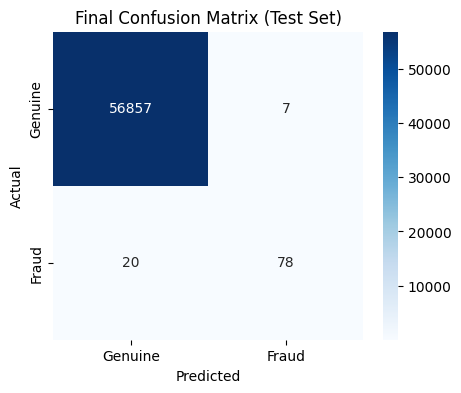

In [40]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Genuine", "Fraud"], yticklabels=["Genuine", "Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final Confusion Matrix (Test Set)")
plt.savefig('images/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


Precision-Recall and ROC curves for the final model. **PR curves are more informative than ROC curves on highly imbalanced data** like this, since ROC-AUC can look deceptively good even when precision on the minority class is poor.

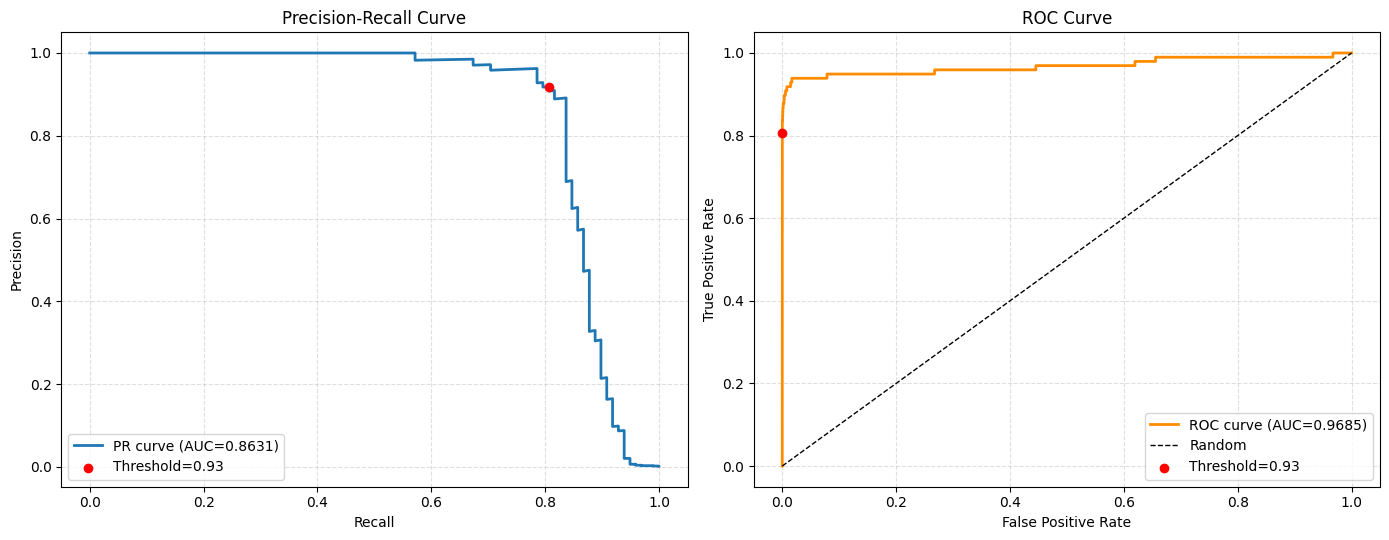

Test PR-AUC: 0.8631  |  Test ROC-AUC: 0.9685


In [41]:
pr_p, pr_r, pr_thresholds = precision_recall_curve(y_test, y_probs)
fpr, tpr, roc_thresholds = roc_curve(y_test, y_probs)
pr_auc = average_precision_score(y_test, y_probs)
roc_auc = roc_auc_score(y_test, y_probs)

opt_idx_pr = int(np.argmin(np.abs(pr_thresholds - best_threshold)))
opt_idx_roc = int(np.argmin(np.abs(roc_thresholds - best_threshold)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].plot(pr_r, pr_p, lw=2, label=f"PR curve (AUC={pr_auc:.4f})")
axes[0].scatter(pr_r[opt_idx_pr], pr_p[opt_idx_pr], color="red", zorder=5,
                 label=f"Threshold={best_threshold:.2f}")
axes[0].set_title("Precision-Recall Curve")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].legend(loc="lower left"); axes[0].grid(alpha=0.4, linestyle="--")

axes[1].plot(fpr, tpr, lw=2, color="darkorange", label=f"ROC curve (AUC={roc_auc:.4f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="Random")
axes[1].scatter(fpr[opt_idx_roc], tpr[opt_idx_roc], color="red", zorder=5,
                 label=f"Threshold={best_threshold:.2f}")
axes[1].set_title("ROC Curve")
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right"); axes[1].grid(alpha=0.4, linestyle="--")

plt.tight_layout()
plt.savefig('images/pr_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Test PR-AUC: {pr_auc:.4f}  |  Test ROC-AUC: {roc_auc:.4f}")

**Observation:** At the tuned threshold (0.93), the model catches roughly 80% of fraud (recall) while keeping precision around 92% — meaning only a small fraction of flagged transactions are false alarms. PR-AUC of 0.86 is strong for a problem this imbalanced. ROC-AUC (0.97) looks even better, but as noted earlier that's partly an artifact of the huge class imbalance inflating the true-negative rate — PR-AUC is the more honest measure of how well the model actually separates fraud from genuine transactions here.

## 10. Feature Importance

Which original features contributed most to the model's fraud predictions — useful for interpretability, even though `V1`–`V28` are anonymized PCA components rather than raw business features.

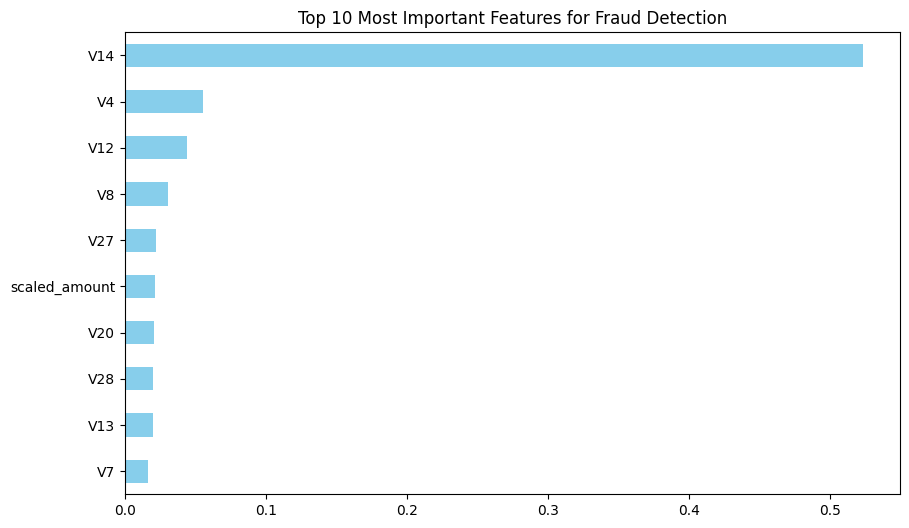

In [42]:
# Extract feature importances from fitted model inside pipeline
fitted_model = best_model.named_steps['model']
importances = pd.Series(
    fitted_model.feature_importances_, index=X_train.columns
)

plt.figure(figsize=(10, 6))
importances.nlargest(10).plot(kind='barh', color='skyblue')
plt.title('Top 10 Most Important Features for Fraud Detection')
plt.gca().invert_yaxis()
plt.savefig('images/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Save the Model

Saving both the fitted pipeline **and** the tuned decision threshold together, since the threshold is only meaningful paired with this specific model — a different model/retrain would need its own re-tuned threshold.

In [43]:
import joblib
joblib.dump({"pipeline": best_model, "threshold": best_threshold}, "fraud_model.joblib")
print("Saved: fraud_model.joblib")

Saved: fraud_model.joblib


## 12. Download Figures (Google Colab)

Zips the `images/` folder and triggers a browser download, since Colab's filesystem doesn't persist between sessions. Drop the extracted PNGs into an `images/` folder in your GitHub repo and reference them in the README (e.g. `![Confusion Matrix](images/confusion_matrix.png)`).

In [44]:
import shutil
shutil.make_archive('figures', 'zip', 'images')

try:
    from google.colab import files
    files.download('figures.zip')
except ImportError:
    print("Not running in Colab — find the zipped figures at 'figures.zip' in the working directory.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>